# 01. 데이터 및 종목 Universe 감사

모델을 만들기 전에 **어떤 종목이 왜 수집되었는지**, 수집 대상이 실시간 후보 종목 선정 방식과 일치하는지, negative coverage가 충분한지를 확인한다.

이 노트북은 다음 항목을 감사한다.

- 세션 수, 종목 수, 반복 등장 종목
- manifest의 rank, 가격, 거래대금, security type 분포
- manifest와 `*_enriched.csv` 파일의 일치 여부
- OHLC 무결성, 중복 timestamp, 1분봉 gap
- 수집된 종목 내 단순 상승·하락 결과 분포
- selection bias와 negative coverage에 대한 자동 진단

> 주의: 이 데이터만으로는 수집되지 않은 전체 미국 주식 universe와 직접 비교할 수 없다. 따라서 selection bias의 원인을 확정하는 것이 아니라, 현재 데이터가 어떤 조건으로 제한되어 있는지 먼저 드러내는 단계다.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else None
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Noto Sans CJK KR", "Noto Sans CJK JP"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False


## 1. 경로와 세션 탐색

데이터 경로는 현재 실행 디렉터리가 아니라 프로젝트 루트를 기준으로 해석한다. 원본 데이터는 읽기 전용으로 취급한다.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "AGENT.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("AGENT.md와 README.md가 있는 프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = (PROJECT_ROOT / "../../data/stock_data").resolve()
RAW_ROOT = DATA_ROOT / "raw"
SESSION_DIRS = sorted(path for path in RAW_ROOT.glob("session_*") if path.is_dir())
MANIFEST_PATHS = [path / "collection_manifest.json" for path in SESSION_DIRS]

assert DATA_ROOT.exists(), f"데이터 루트가 없습니다: {DATA_ROOT}"
assert SESSION_DIRS, f"세션 디렉터리가 없습니다: {RAW_ROOT}"
assert all(path.exists() for path in MANIFEST_PATHS), "manifest가 없는 세션이 있습니다."

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_ROOT:    {DATA_ROOT}")
print(f"세션 수:      {len(SESSION_DIRS):,}")


PROJECT_ROOT: /home/user/urbandatalab/YSLee/code/Detecting-entry-signals-for-short-term-trades-right-before-a-rapid-price-surge
DATA_ROOT:    /home/user/urbandatalab/YSLee/data/stock_data
세션 수:      9


## 2. Manifest 적재

세션 설정과 종목 선정 정보를 표 형태로 변환한다.

In [3]:
session_rows: list[dict] = []
universe_rows: list[dict] = []

for manifest_path in MANIFEST_PATHS:
    with manifest_path.open(encoding="utf-8") as file:
        manifest = json.load(file)

    session = manifest_path.parent.name
    window = manifest.get("window_kst", [None, None])
    symbols = manifest.get("symbols", [])
    session_rows.append({
        "session": session,
        "window_start_kst": window[0] if len(window) > 0 else None,
        "window_end_kst": window[1] if len(window) > 1 else None,
        "max_price": manifest.get("max_price"),
        "include_etf": manifest.get("include_etf"),
        "manifest_symbol_count": len(symbols),
        "manifest_path": str(manifest_path),
    })

    for item in symbols:
        row = dict(item)
        row["session"] = session
        row["window_start_kst"] = window[0] if len(window) > 0 else None
        row["window_end_kst"] = window[1] if len(window) > 1 else None
        row["session_max_price"] = manifest.get("max_price")
        row["session_include_etf"] = manifest.get("include_etf")
        enriched_name = item.get("enriched")
        row["enriched_path"] = str(manifest_path.parent / enriched_name) if enriched_name else None
        row["enriched_exists"] = bool(enriched_name and (manifest_path.parent / enriched_name).exists())
        universe_rows.append(row)

session_df = pd.DataFrame(session_rows).sort_values("session").reset_index(drop=True)
universe_df = pd.DataFrame(universe_rows)

for column in ["rank", "price", "trade_amount_usd", "bars", "quotes", "trades"]:
    if column in universe_df:
        universe_df[column] = pd.to_numeric(universe_df[column], errors="coerce")
universe_df["symbol"] = universe_df["symbol"].astype(str).str.upper()

display(session_df.drop(columns="manifest_path"))
display(universe_df.head())


,session,window_start_kst,window_end_kst,max_price,include_etf,manifest_symbol_count
0,session_2026-07-07,2026-07-07 17:00,2026-07-08 08:00,20.0,False,14
1,session_2026-07-08,2026-07-08 17:00,2026-07-09 08:00,20.0,False,25
2,session_2026-07-09,2026-07-09 17:00,2026-07-10 08:00,20.0,False,33
3,session_2026-07-10,2026-07-10 17:00,2026-07-11 08:00,20.0,False,34
4,session_2026-07-13,2026-07-13 17:00,2026-07-14 08:00,20.0,False,21
5,session_2026-07-14,2026-07-14 17:00,2026-07-15 08:00,20.0,False,20
6,session_2026-07-15,2026-07-15 17:00,2026-07-16 08:00,20.0,False,23
7,session_2026-07-16,2026-07-16 17:00,2026-07-17 08:00,20.0,False,17
8,session_2026-07-17,2026-07-17 17:00,2026-07-18 08:00,20.0,False,21


,symbol,rank,price,trade_amount_usd,security_type,enriched,bars,quotes,trades,status,session,window_start_kst,window_end_kst,session_max_price,session_include_etf,enriched_path,enriched_exists,forced_include,reason
0,DCX,11.0,1.3900,526372046.0,STOCK,dcx_2026-07-07_1700-0800_kst_02d88b1e_enriched...,165.0,19819.0,38253.0,ok,session_2026-07-07,2026-07-07 17:00,2026-07-08 08:00,20.0,False,/home/user/urbandatalab/YSLee/data/stock_data/...,True,NaN,NaN
1,IOTR,16.0,3.6800,285336351.0,STOCK,iotr_2026-07-07_1700-0800_kst_87def31a_enriche...,170.0,26656.0,79679.0,ok,session_2026-07-07,2026-07-07 17:00,2026-07-08 08:00,20.0,False,/home/user/urbandatalab/YSLee/data/stock_data/...,True,NaN,NaN
2,VEEE,17.0,7.2800,259741923.0,STOCK,veee_2026-07-07_1700-0800_kst_03e9f283_enriche...,183.0,6256.0,18358.0,ok,session_2026-07-07,2026-07-07 17:00,2026-07-08 08:00,20.0,False,/home/user/urbandatalab/YSLee/data/stock_data/...,True,NaN,NaN
3,TC,44.0,2.7200,83929994.0,DEPOSITARY_RECEIPT,tc_2026-07-07_1700-0800_kst_b0a80026_enriched.csv,447.0,17875.0,47692.0,ok,session_2026-07-07,2026-07-07 17:00,2026-07-08 08:00,20.0,False,/home/user/urbandatalab/YSLee/data/stock_data/...,True,NaN,NaN
4,VTAK,45.0,0.8824,83905222.0,STOCK,vtak_2026-07-07_1700-0800_kst_47dd3997_enriche...,324.0,43925.0,74724.0,ok,session_2026-07-07,2026-07-07 17:00,2026-07-08 08:00,20.0,False,/home/user/urbandatalab/YSLee/data/stock_data/...,True,NaN,NaN


## 3. Universe 전체 요약

,value
sessions,9.000000
symbol_session_rows,208.000000
unique_symbols,125.000000
symbols_seen_multiple_sessions,47.000000
repeat_symbol_session_share,0.399038
missing_enriched_files,0.000000
manifest_status_skipped,57.000000


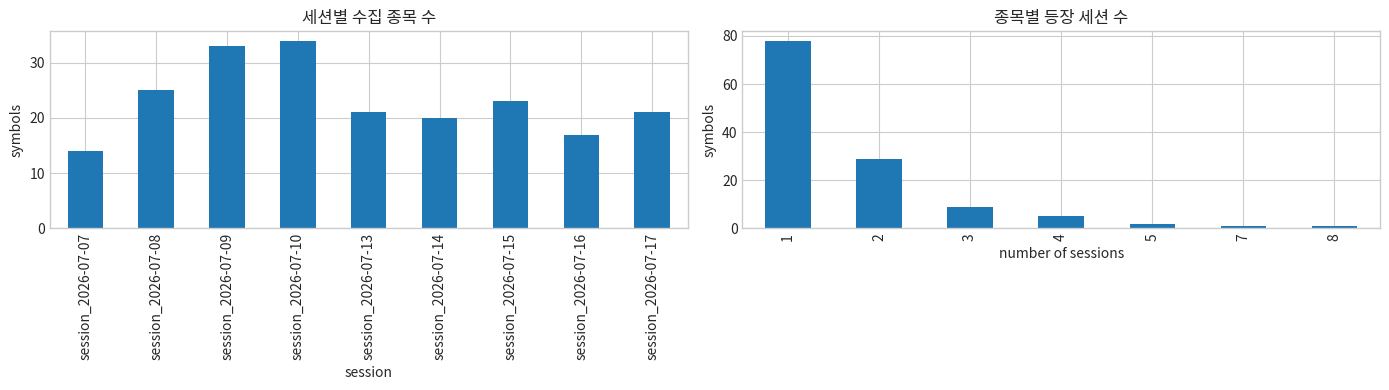

,session_count
symbol,
JLHL,8
SKYQ,7
BATL,5
VMAR,5
ELPW,4
VTAK,4
SUNE,4
GCTK,4
YHC,4


In [4]:
symbol_session_counts = universe_df.groupby("symbol")["session"].nunique().sort_values(ascending=False)
overview = pd.Series({
    "sessions": session_df["session"].nunique(),
    "symbol_session_rows": len(universe_df),
    "unique_symbols": universe_df["symbol"].nunique(),
    "symbols_seen_multiple_sessions": int((symbol_session_counts > 1).sum()),
    "repeat_symbol_session_share": 1 - universe_df["symbol"].nunique() / max(len(universe_df), 1),
    "missing_enriched_files": int((~universe_df["enriched_exists"]).sum()),
    "manifest_status_skipped": int(universe_df["status"].fillna("missing").eq("skipped").sum()),
}, name="value")
display(overview.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
session_df.plot.bar(x="session", y="manifest_symbol_count", ax=axes[0], legend=False, title="세션별 수집 종목 수")
symbol_session_counts.value_counts().sort_index().plot.bar(ax=axes[1], title="종목별 등장 세션 수")
axes[0].set_ylabel("symbols")
axes[1].set_xlabel("number of sessions")
axes[1].set_ylabel("symbols")
plt.tight_layout()
plt.show()

display(symbol_session_counts.head(20).rename("session_count").to_frame())


## 4. 종목 선정 특성

rank와 거래대금은 수집 후보 선정 편향을 파악하기 위한 감사 정보로만 사용하며 모델 입력에는 사용하지 않는다.

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
rank,207.0,5.481643e+01,3.045903e+01,1.000000e+00,2.000000e+00,1.000000e+01,2.800000e+01,60.00,8.400000e+01,9.240000e+01,9.994000e+01,1.000000e+02
price,207.0,3.319083e+00,3.997436e+00,2.340000e-02,3.678400e-02,2.861400e-01,6.907500e-01,1.54,4.095000e+00,8.914000e+00,1.566600e+01,1.851000e+01
trade_amount_usd,207.0,2.323466e+08,5.993513e+08,1.153043e+07,1.204041e+07,1.902658e+07,2.632256e+07,44272486.00,1.162546e+08,6.791745e+08,1.903746e+09,6.120224e+09


session,session_2026-07-07,session_2026-07-08,session_2026-07-09,session_2026-07-10,session_2026-07-13,session_2026-07-14,session_2026-07-15,session_2026-07-16,session_2026-07-17,All
security_type,,,,,,,,,,
DEPOSITARY_RECEIPT,1,0,0,0,1,0,0,0,0,2
STOCK,13,25,33,34,20,20,23,17,21,206
All,14,25,33,34,21,20,23,17,21,208


,rows
rank,
1-10,25
11-25,25
26-50,36
51-100,121
101-250,0
251-500,0
501+,0


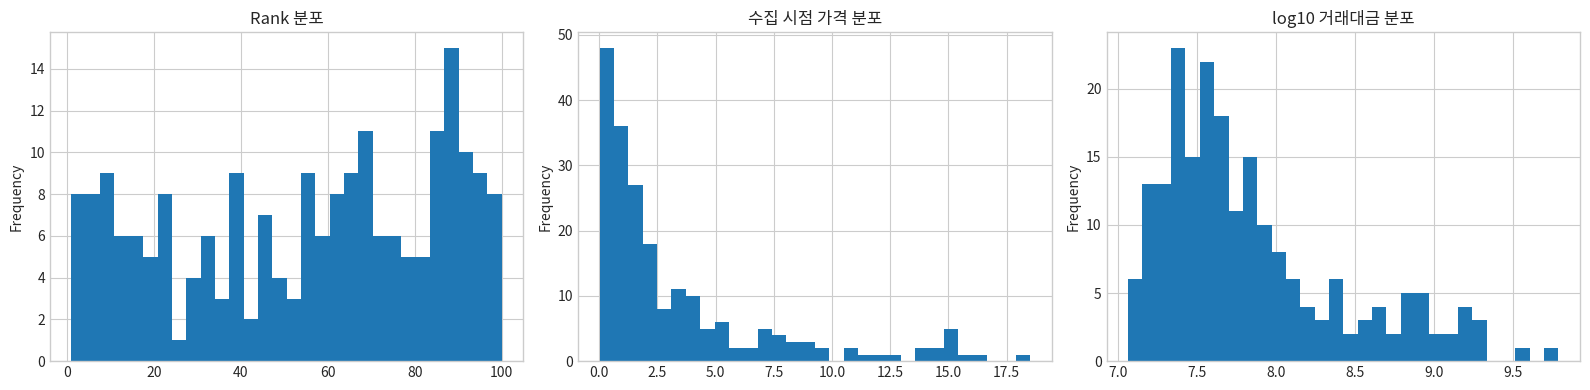

In [5]:
selection_columns = ["rank", "price", "trade_amount_usd"]
display(universe_df[selection_columns].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T)

if "security_type" in universe_df:
    display(pd.crosstab(universe_df["security_type"], universe_df["session"], margins=True))

rank_bands = pd.cut(
    universe_df["rank"],
    bins=[0, 10, 25, 50, 100, 250, 500, np.inf],
    labels=["1-10", "11-25", "26-50", "51-100", "101-250", "251-500", "501+"],
)
display(rank_bands.value_counts(sort=False).rename("rows").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
universe_df["rank"].dropna().plot.hist(bins=30, ax=axes[0], title="Rank 분포")
universe_df["price"].dropna().plot.hist(bins=30, ax=axes[1], title="수집 시점 가격 분포")
np.log10(universe_df.loc[universe_df["trade_amount_usd"] > 0, "trade_amount_usd"]).plot.hist(
    bins=30, ax=axes[2], title="log10 거래대금 분포"
)
plt.tight_layout()
plt.show()


## 5. Enriched 파일 무결성과 단순 결과 분포

모든 enriched 파일에서 필요한 최소 컬럼만 읽는다. `session_return`과 `max_runup_from_first_open`은 negative coverage를 대략 살펴보기 위한 감사 지표이며 학습 라벨이 아니다.

In [6]:
REQUIRED_COLUMNS = ["symbol", "timestamp_kst", "timestamp_utc", "open", "high", "low", "close"]
file_rows: list[dict] = []

for row in universe_df.itertuples(index=False):
    path = Path(row.enriched_path) if row.enriched_path else None
    result = {
        "session": row.session,
        "manifest_symbol": row.symbol,
        "enriched_path": str(path) if path else None,
        "file_exists": bool(path and path.exists()),
    }
    if not path or not path.exists():
        file_rows.append(result)
        continue

    header = pd.read_csv(path, nrows=0, encoding="utf-8-sig").columns.tolist()
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(header))
    result["missing_required_columns"] = ",".join(missing_columns)
    if missing_columns:
        file_rows.append(result)
        continue

    frame = pd.read_csv(path, usecols=REQUIRED_COLUMNS, encoding="utf-8-sig")
    for column in ["open", "high", "low", "close"]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame["timestamp_utc"] = pd.to_datetime(frame["timestamp_utc"], errors="coerce", utc=True)
    frame = frame.sort_values("timestamp_utc").reset_index(drop=True)

    duplicate_count = int(frame.duplicated(["symbol", "timestamp_utc"]).sum())
    delta_minutes = frame["timestamp_utc"].diff().dt.total_seconds().div(60)
    is_consecutive = pd.Series(
        np.isclose(delta_minutes, 1.0, rtol=0.0, atol=1e-6),
        index=frame.index,
    )
    run_id = (~is_consecutive).cumsum()
    run_lengths = frame.groupby(run_id, sort=False).size()
    ohlc_invalid = (
        frame[["open", "high", "low", "close"]].isna().any(axis=1)
        | (frame[["open", "high", "low", "close"]] <= 0).any(axis=1)
        | (frame["high"] < frame[["open", "close"]].max(axis=1))
        | (frame["low"] > frame[["open", "close"]].min(axis=1))
        | (frame["high"] < frame["low"])
    )

    first_open = frame["open"].iloc[0] if len(frame) else np.nan
    last_close = frame["close"].iloc[-1] if len(frame) else np.nan
    result.update({
        "rows": len(frame),
        "symbols_in_file": frame["symbol"].nunique(dropna=True),
        "symbol_matches_manifest": bool(len(frame) and set(frame["symbol"].dropna().str.upper().unique()) == {row.symbol}),
        "start_utc": frame["timestamp_utc"].min(),
        "end_utc": frame["timestamp_utc"].max(),
        "duplicate_timestamps": duplicate_count,
        # 부동소수점 오차로 1분이 1.0000000000000002가 될 수 있으므로 1.5분을 경계로 사용한다.
        "gap_count_gt_1m": int((delta_minutes > 1.5).sum()),
        "nonpositive_or_reversed_delta": int((delta_minutes <= 0).sum()),
        "max_consecutive_bars": int(run_lengths.max()) if len(run_lengths) else 0,
        "possible_60bar_windows": int((run_lengths - 60 + 1).clip(lower=0).sum()),
        "invalid_ohlc_rows": int(ohlc_invalid.sum()),
        "session_return": last_close / first_open - 1 if first_open > 0 else np.nan,
        "max_runup_from_first_open": frame["high"].max() / first_open - 1 if first_open > 0 else np.nan,
        "max_drawdown_from_first_open": frame["low"].min() / first_open - 1 if first_open > 0 else np.nan,
    })
    file_rows.append(result)

file_audit_df = pd.DataFrame(file_rows)
display(file_audit_df.head())
print(f"감사한 enriched 파일: {file_audit_df['file_exists'].sum():,}")


,session,manifest_symbol,enriched_path,file_exists,missing_required_columns,rows,symbols_in_file,symbol_matches_manifest,start_utc,end_utc,duplicate_timestamps,gap_count_gt_1m,nonpositive_or_reversed_delta,max_consecutive_bars,possible_60bar_windows,invalid_ohlc_rows,session_return,max_runup_from_first_open,max_drawdown_from_first_open
0,session_2026-07-07,DCX,/home/user/urbandatalab/YSLee/data/stock_data/...,True,,165,1,True,2026-07-07 13:55:00+00:00,2026-07-07 23:00:00+00:00,0,36,0,123,64,0,0.284314,0.519608,-0.063725
1,session_2026-07-07,IOTR,/home/user/urbandatalab/YSLee/data/stock_data/...,True,,170,1,True,2026-07-07 13:30:00+00:00,2026-07-07 23:00:00+00:00,0,18,0,147,88,0,0.405303,0.761250,-0.049242
2,session_2026-07-07,VEEE,/home/user/urbandatalab/YSLee/data/stock_data/...,True,,183,1,True,2026-07-07 13:30:00+00:00,2026-07-07 23:00:00+00:00,0,41,0,29,0,0,0.461980,0.529412,-0.039216
3,session_2026-07-07,TC,/home/user/urbandatalab/YSLee/data/stock_data/...,True,,447,1,True,2026-07-07 08:00:00+00:00,2026-07-07 23:00:00+00:00,0,137,0,121,62,0,0.143364,0.382672,-0.104808
4,session_2026-07-07,VTAK,/home/user/urbandatalab/YSLee/data/stock_data/...,True,,324,1,True,2026-07-07 08:03:00+00:00,2026-07-07 23:00:00+00:00,0,83,0,166,107,0,0.232232,0.678468,-0.200105


감사한 enriched 파일: 208


,value
missing_files,0
files_missing_required_columns,0
files_with_symbol_mismatch,0
total_duplicate_timestamps,0
total_invalid_ohlc_rows,0
files_with_gaps,195
total_gaps,11785
files_with_at_least_one_60bar_window,181
possible_60bar_windows_before_label_filter,65666


,count,mean,std,min,10%,25%,50%,75%,90%,max
session_return,208.0,0.105258,0.418976,-0.715688,-0.226114,-0.097822,0.015042,0.241651,0.531390,4.040712
max_runup_from_first_open,208.0,0.560416,1.066962,0.000000,0.023481,0.088200,0.327077,0.601289,1.222322,11.530000
max_drawdown_from_first_open,208.0,-0.137854,0.136606,-0.746330,-0.301078,-0.196520,-0.096222,-0.042480,-0.017250,0.000000


,share
nonpositive_session_return_share,0.466346
runup_below_1pct_share,0.043269
runup_below_3pct_share,0.125000
runup_below_5pct_share,0.163462


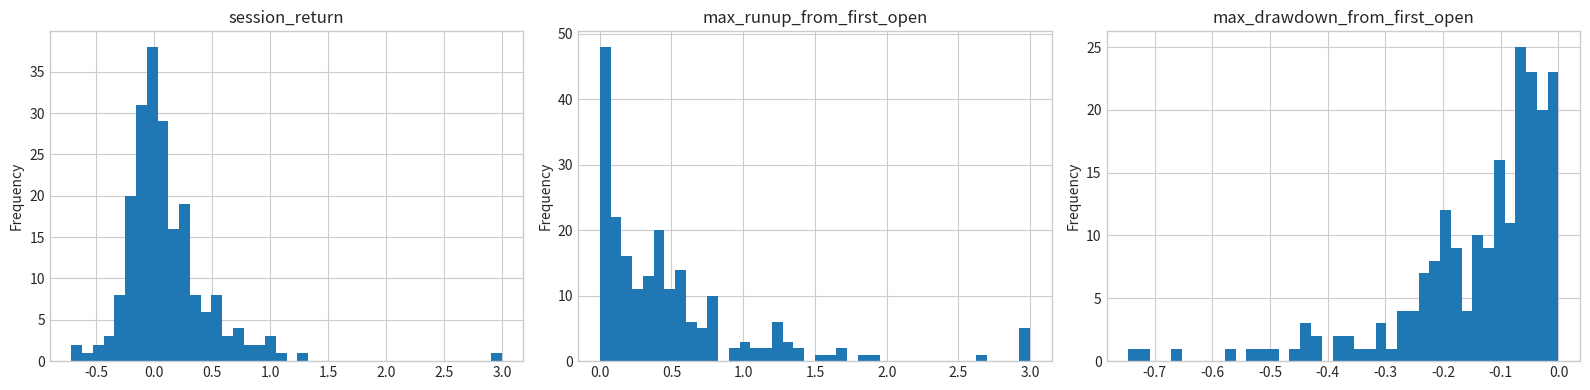

In [7]:
quality_summary = pd.Series({
    "missing_files": int((~file_audit_df["file_exists"]).sum()),
    "files_missing_required_columns": int(file_audit_df["missing_required_columns"].fillna("").ne("").sum()),
    "files_with_symbol_mismatch": int((file_audit_df["symbol_matches_manifest"] == False).sum()),  # noqa: E712
    "total_duplicate_timestamps": int(file_audit_df["duplicate_timestamps"].fillna(0).sum()),
    "total_invalid_ohlc_rows": int(file_audit_df["invalid_ohlc_rows"].fillna(0).sum()),
    "files_with_gaps": int(file_audit_df["gap_count_gt_1m"].fillna(0).gt(0).sum()),
    "total_gaps": int(file_audit_df["gap_count_gt_1m"].fillna(0).sum()),
    "files_with_at_least_one_60bar_window": int(file_audit_df["possible_60bar_windows"].fillna(0).gt(0).sum()),
    "possible_60bar_windows_before_label_filter": int(file_audit_df["possible_60bar_windows"].fillna(0).sum()),
}, name="value")
display(quality_summary.to_frame())

outcome_columns = ["session_return", "max_runup_from_first_open", "max_drawdown_from_first_open"]
display(file_audit_df[outcome_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T)

negative_proxies = pd.Series({
    "nonpositive_session_return_share": file_audit_df["session_return"].le(0).mean(),
    "runup_below_1pct_share": file_audit_df["max_runup_from_first_open"].lt(0.01).mean(),
    "runup_below_3pct_share": file_audit_df["max_runup_from_first_open"].lt(0.03).mean(),
    "runup_below_5pct_share": file_audit_df["max_runup_from_first_open"].lt(0.05).mean(),
}, name="share")
display(negative_proxies.to_frame())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, column in zip(axes, outcome_columns):
    file_audit_df[column].clip(-1, 3).plot.hist(bins=40, ax=axis, title=column)
plt.tight_layout()
plt.show()


## 6. 자동 진단과 다음 결정

아래 진단은 모델 개발을 막는 절대 규칙이 아니라, 먼저 확인해야 할 위험을 보여준다.

In [8]:
findings: list[str] = []
session_count = int(session_df["session"].nunique())
unique_symbol_count = int(universe_df["symbol"].nunique())
repeat_share = float(overview["repeat_symbol_session_share"])
median_rank = float(universe_df["rank"].median())
rank_100_share = float(universe_df["rank"].le(100).mean())
negative_return_share = float(negative_proxies["nonpositive_session_return_share"])
runup_3pct_share = 1.0 - float(negative_proxies["runup_below_3pct_share"])
files_with_gaps = int(quality_summary["files_with_gaps"])
possible_60bar_windows = int(quality_summary["possible_60bar_windows_before_label_filter"])
files_with_60bar_windows = int(quality_summary["files_with_at_least_one_60bar_window"])
skipped_manifest_rows = int(overview["manifest_status_skipped"])

if session_count < 20:
    findings.append(f"**높은 위험 — 날짜 표본 부족:** 세션이 {session_count}개뿐이어서 train/validation/test 날짜 일반화를 신뢰하기 어렵다.")
else:
    findings.append(f"**확인:** 총 {session_count}개 세션이 있다. 월별·시장 국면별 분포를 추가 확인한다.")

findings.append(
    f"**Selection bias 확인 필요:** manifest rank 중앙값은 {median_rank:,.0f}, rank 100 이내 비중은 {rank_100_share:.1%}다. "
    "거래대금 상위 후보를 먼저 고르는 운영 구조라면 이 선별기를 학습·백테스트·실시간에 동일하게 적용해야 한다."
)
findings.append(
    f"**종목 반복성:** 고유 종목 {unique_symbol_count:,}개, symbol-session 중 반복 등장분 비중은 {repeat_share:.1%}다. "
    "동일 종목의 날짜 간 의존성을 고려해 날짜 기반 split을 유지해야 한다."
)
findings.append(
    f"**Negative proxy:** 전체 세션 수익률이 0 이하인 파일 비중은 {negative_return_share:.1%}다. "
    "다만 이는 10분 진입 라벨의 negative 비율이 아니므로, Dual-path 라벨 생성 후 시점 단위 class balance를 다시 측정해야 한다."
)
findings.append(
    f"**급등 후보 편향 신호:** 첫 시가 대비 세션 중 3% 이상 상승한 파일 비중이 {runup_3pct_share:.1%}다. "
    "일반 종목 universe와 비교하기 전에는 이 데이터를 전체 미국 주식 분포로 간주하면 안 된다."
)
findings.append(
    f"**1분봉 연속성:** {len(file_audit_df)}개 중 {files_with_gaps}개 파일에 1분 초과 gap이 있다. "
    f"현재 gap 제외 규칙으로 60봉 입력을 만들 수 있는 파일은 {files_with_60bar_windows}개이고, "
    f"라벨 구간 제외 전 가능한 60봉 window는 {possible_60bar_windows:,}개다. "
    "무거래 분과 수집 누락을 구분한 뒤 최종 제외 정책을 확정해야 한다."
)
if skipped_manifest_rows:
    findings.append(
        f"**Manifest 상태 확인:** `status=skipped`가 {skipped_manifest_rows}건이지만 대응 enriched 파일은 존재한다. "
        "기존 파일 재사용을 뜻하는지 수집 일부 실패를 뜻하는지 수집기 규칙을 확인해야 한다."
    )

if int(quality_summary["missing_files"]) or int(quality_summary["total_invalid_ohlc_rows"]):
    findings.append("**데이터 품질 조치 필요:** 누락 파일 또는 OHLC 오류가 있으므로 dataset 생성 전에 제외 규칙을 적용한다.")
else:
    findings.append("**기본 무결성 통과:** manifest 파일 존재 여부, 종목 일치 및 OHLC 기본 조건에서는 즉시 차단할 오류가 발견되지 않았다. timestamp gap은 위 항목에서 별도로 판단한다.")

findings.append(
    "**다음 결정:** 실시간에도 동일한 종목 선별기를 사용할지 확정하고, 사용하지 않는다면 일반 종목·실패 후보를 추가 수집한 뒤 모델 학습을 시작한다."
)

display(Markdown("### 감사 결론\n\n" + "\n\n".join(f"- {item}" for item in findings)))


### 감사 결론

- **높은 위험 — 날짜 표본 부족:** 세션이 9개뿐이어서 train/validation/test 날짜 일반화를 신뢰하기 어렵다.

- **Selection bias 확인 필요:** manifest rank 중앙값은 60, rank 100 이내 비중은 99.5%다. 거래대금 상위 후보를 먼저 고르는 운영 구조라면 이 선별기를 학습·백테스트·실시간에 동일하게 적용해야 한다.

- **종목 반복성:** 고유 종목 125개, symbol-session 중 반복 등장분 비중은 39.9%다. 동일 종목의 날짜 간 의존성을 고려해 날짜 기반 split을 유지해야 한다.

- **Negative proxy:** 전체 세션 수익률이 0 이하인 파일 비중은 46.6%다. 다만 이는 10분 진입 라벨의 negative 비율이 아니므로, Dual-path 라벨 생성 후 시점 단위 class balance를 다시 측정해야 한다.

- **급등 후보 편향 신호:** 첫 시가 대비 세션 중 3% 이상 상승한 파일 비중이 87.5%다. 일반 종목 universe와 비교하기 전에는 이 데이터를 전체 미국 주식 분포로 간주하면 안 된다.

- **1분봉 연속성:** 208개 중 195개 파일에 1분 초과 gap이 있다. 현재 gap 제외 규칙으로 60봉 입력을 만들 수 있는 파일은 181개이고, 라벨 구간 제외 전 가능한 60봉 window는 65,666개다. 무거래 분과 수집 누락을 구분한 뒤 최종 제외 정책을 확정해야 한다.

- **Manifest 상태 확인:** `status=skipped`가 57건이지만 대응 enriched 파일은 존재한다. 기존 파일 재사용을 뜻하는지 수집 일부 실패를 뜻하는지 수집기 규칙을 확인해야 한다.

- **기본 무결성 통과:** manifest 파일 존재 여부, 종목 일치 및 OHLC 기본 조건에서는 즉시 차단할 오류가 발견되지 않았다. timestamp gap은 위 항목에서 별도로 판단한다.

- **다음 결정:** 실시간에도 동일한 종목 선별기를 사용할지 확정하고, 사용하지 않는다면 일반 종목·실패 후보를 추가 수집한 뒤 모델 학습을 시작한다.

## 7. 후속 작업 체크리스트

- [ ] 실시간 종목 후보 선별 규칙을 문서화한다.
- [ ] manifest의 `rank`가 어느 전체 universe를 기준으로 계산됐는지 확인한다.
- [ ] 수집에서 제외된 종목과 실패한 후보를 확보할 수 있는지 확인한다.
- [ ] 최소 여러 주와 서로 다른 시장 국면의 세션을 확보한다.
- [ ] Dual-path 라벨 생성 후 시점 단위 positive/negative/ambiguous 비율을 다시 감사한다.
- [ ] 학습·백테스트·실시간에서 동일한 후보 종목 선별기를 적용한다.
